In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# 한글 폰트 설정 (Colab 환경) - 레이블이 영어이므로 주석 처리됨
# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 예제 데이터 생성
np.random.seed(42)
data_size = 100

df = pd.DataFrame({
    'income': np.random.normal(5000, 1500, data_size).astype(int),
    'expense': np.random.normal(3000, 1000, data_size).astype(int),
    'age': np.random.randint(20, 60, data_size),
    'city': np.random.choice(['Seoul', 'Busan', 'Daegu', 'Incheon'], data_size),
    'gender': np.random.choice(['Male', 'Female'], data_size),
    'satisfaction': np.random.randint(1, 6, data_size),
    'date': pd.date_range(start='2023-01-01', periods=data_size, freq='D')
})

df['income'] = df['income'].apply(lambda x: max(1000, x)) # 최소 수입 설정
df['expense'] = df['expense'].apply(lambda x: max(500, x)) # 최소 지출 설정

print("First 5 rows of the generated DataFrame:")
display(df.head())
print("\nDataFrame Info:")
df.info()

First 5 rows of the generated DataFrame:


,income,expense,age,city,gender,satisfaction,date
0,5745,1584,21,Busan,Male,5,2023-01-01
1,4792,2579,45,Incheon,Female,4,2023-01-02
2,5971,2657,36,Seoul,Male,3,2023-01-03
3,7284,2197,59,Incheon,Male,2,2023-01-04
4,4648,2838,52,Seoul,Female,2,2023-01-05



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   income        100 non-null    int64         
 1   expense       100 non-null    int64         
 2   age           100 non-null    int64         
 3   city          100 non-null    object        
 4   gender        100 non-null    object        
 5   satisfaction  100 non-null    int64         
 6   date          100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 5.6+ KB


### 2. 막대 그래프 (plt.bar)

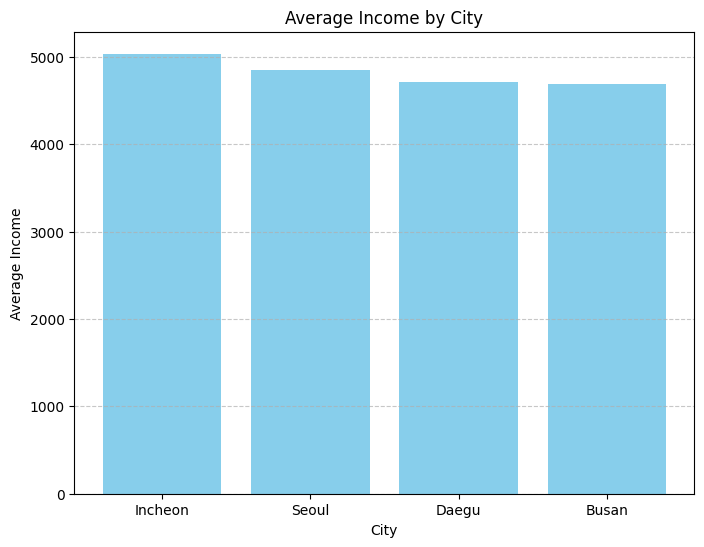

In [ ]:
# 도시별 평균 수입
city_income = df.groupby('city')['income'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.bar(city_income.index, city_income.values, color='skyblue')
plt.xlabel('City')
plt.ylabel('Average Income')
plt.title('Average Income by City')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. 히스토그램 (plt.hist)

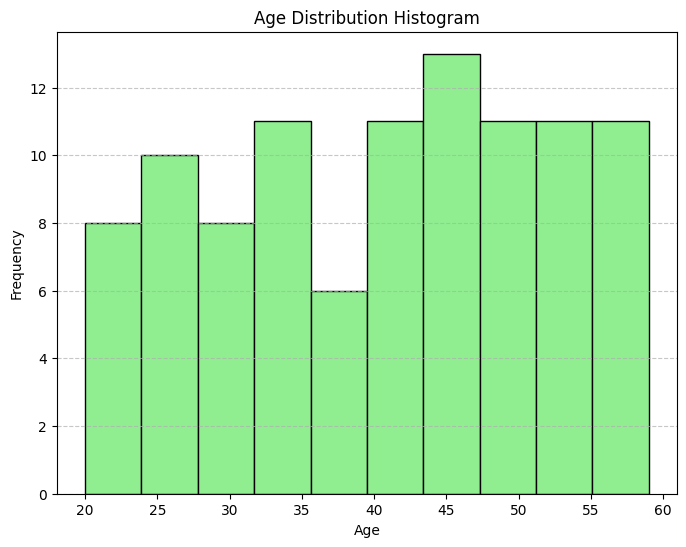

In [ ]:
# 연령 분포 히스토그램
plt.figure(figsize=(8, 6))
plt.hist(df['age'], bins=10, color='lightgreen', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution Histogram')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. 박스 플롯 (pd.boxplot, plt.boxplot)

<Figure size 1000x700 with 0 Axes>

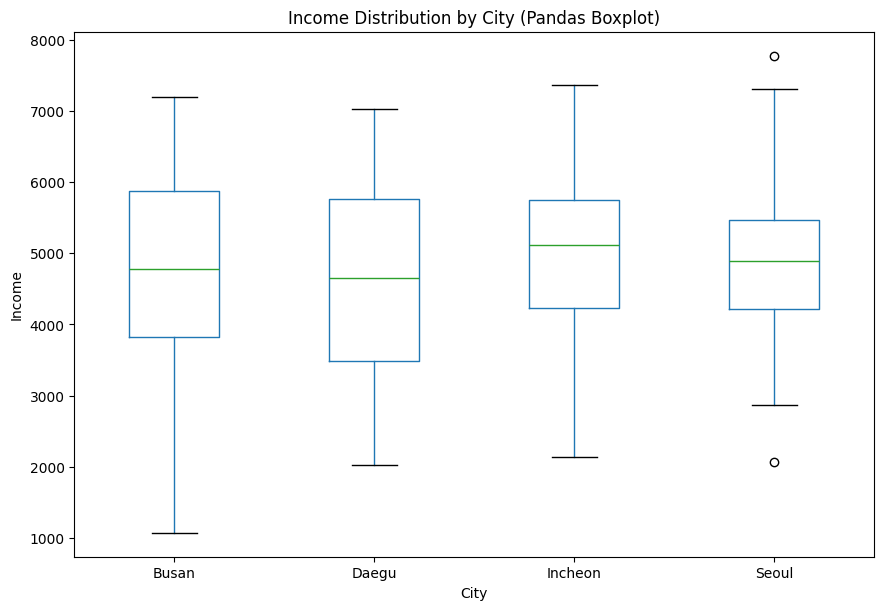

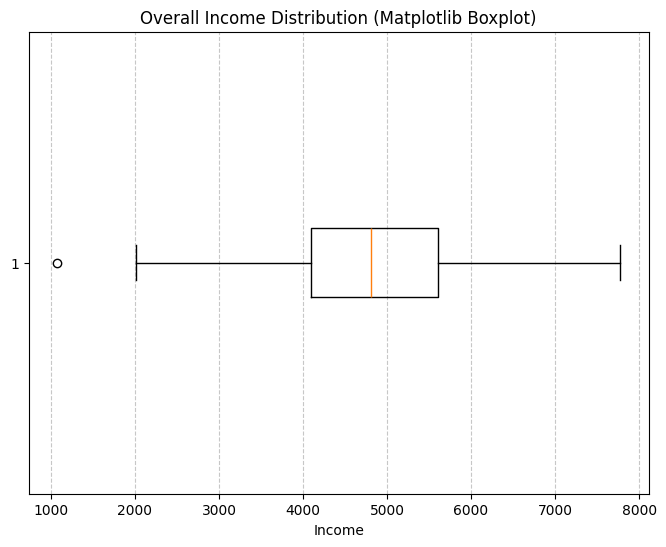

In [ ]:
# Pandas 박스 플롯: 도시별 수입 분포
plt.figure(figsize=(10, 7))
df.boxplot(column='income', by='city', grid=False, figsize=(10, 7))
plt.suptitle('') # 기본 pandas boxplot 제목 제거
plt.title('Income Distribution by City (Pandas Boxplot)')
plt.xlabel('City')
plt.ylabel('Income')
plt.show()

# Matplotlib 박스 플롯: 전체 수입 분포
plt.figure(figsize=(8, 6))
plt.boxplot(df['income'], vert=False) # vert=False로 가로 박스 플롯
plt.xlabel('Income')
plt.title('Overall Income Distribution (Matplotlib Boxplot)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 5. 산점도 (sns.scatterplot)

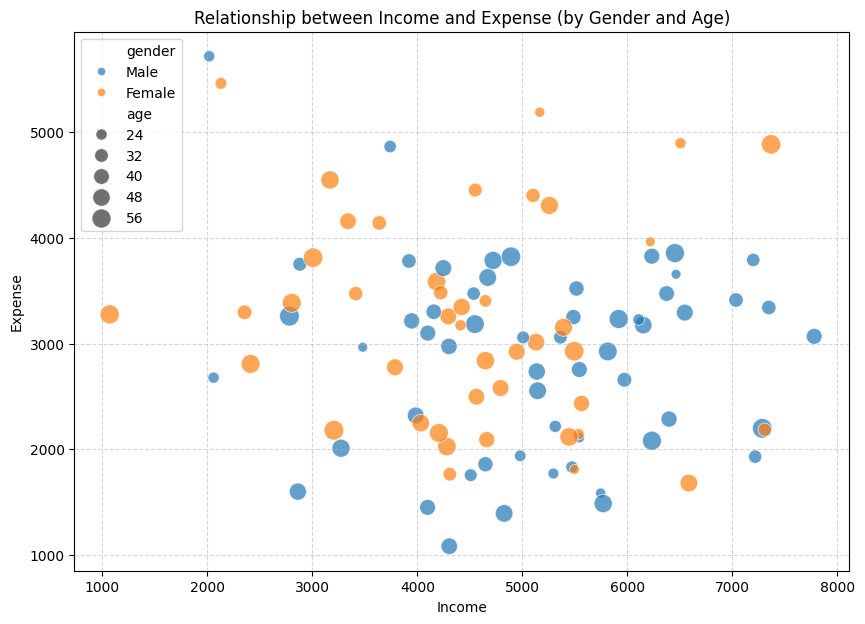

In [ ]:
# 수입과 지출의 관계
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='income', y='expense', hue='gender', size='age', sizes=(50, 200), alpha=0.7)
plt.xlabel('Income')
plt.ylabel('Expense')
plt.title('Relationship between Income and Expense (by Gender and Age)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 6. 선 그래프 (plt.axhline, plt.axvline)

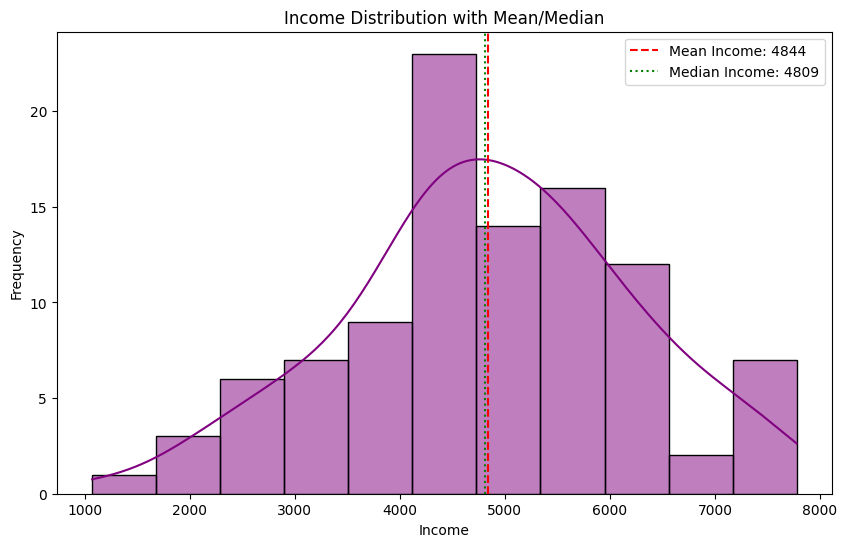

In [ ]:
# 평균/중앙값 표시가 있는 수입 분포
plt.figure(figsize=(10, 6))
sns.histplot(df['income'], kde=True, color='purple')

mean_income = df['income'].mean()
median_income = df['income'].median()

plt.axvline(mean_income, color='red', linestyle='--', label=f'Mean Income: {mean_income:.0f}')
plt.axvline(median_income, color='green', linestyle=':', label=f'Median Income: {median_income:.0f}')

plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Income Distribution with Mean/Median')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.0)
plt.show()

### 7. 함수식 그래프 (plt.plot)

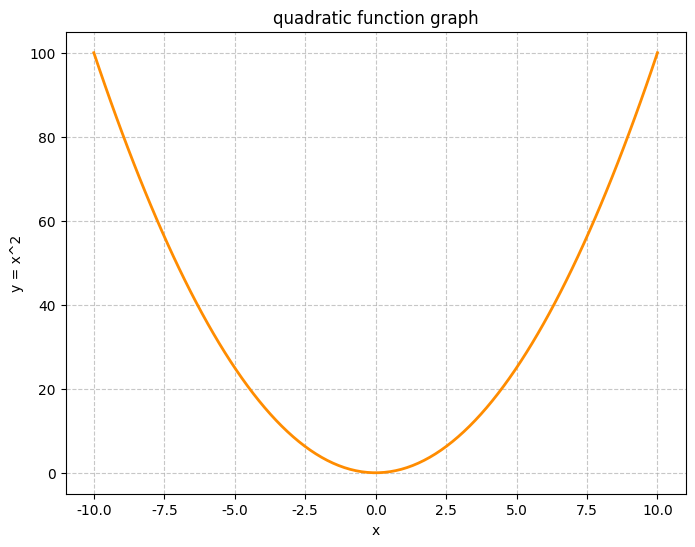

In [ ]:
# 간단한 2차 함수 y = x^2 그래프
x = np.linspace(-10, 10, 100)
y = x**2

plt.figure(figsize=(8, 6))
plt.plot(x, y, color='darkorange', linestyle='-', linewidth=2)
plt.xlabel('x')
plt.ylabel('y = x^2')
plt.title('quadratic function graph')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 8. 회귀선 그래프 (np.polyfit 이용)

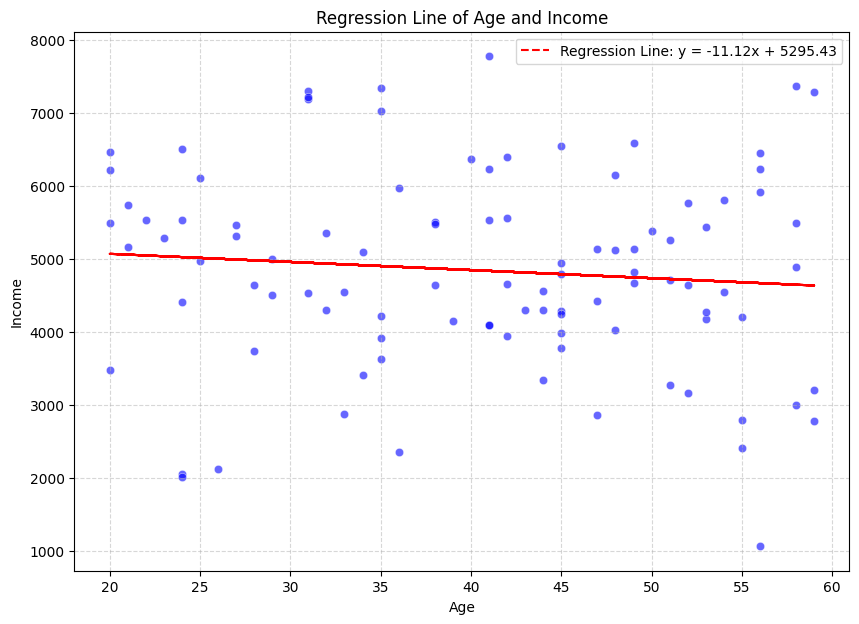

In [ ]:
# 연령과 수입 관계에 대한 회귀선
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='age', y='income', color='blue', alpha=0.6)

# 1차 회귀선 계산 (y = ax + b)
z = np.polyfit(df['age'], df['income'], 1)
p = np.poly1d(z)
plt.plot(df['age'], p(df['age']), color='red', linestyle='--', label=f'Regression Line: y = {z[0]:.2f}x + {z[1]:.2f}')

plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Regression Line of Age and Income')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 9. 꺾은선 그래프 (plt.plot)

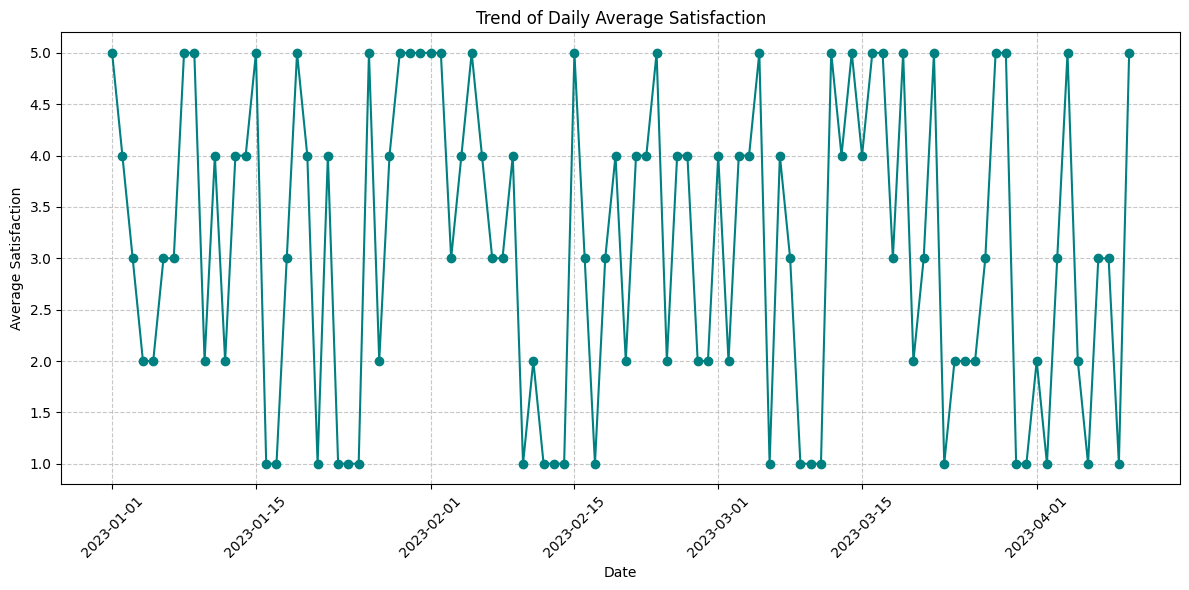

In [ ]:
# 일일 평균 만족도 (시계열)
daily_satisfaction = df.groupby('date')['satisfaction'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_satisfaction['date'], daily_satisfaction['satisfaction'], marker='o', linestyle='-', color='teal')
plt.xlabel('Date')
plt.ylabel('Average Satisfaction')
plt.title('Trend of Daily Average Satisfaction')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10. 상관관계 시각화

#### 10.1 산점도 행렬 (scatter_matrix, sns.pairplot)

<Figure size 1200x1200 with 0 Axes>

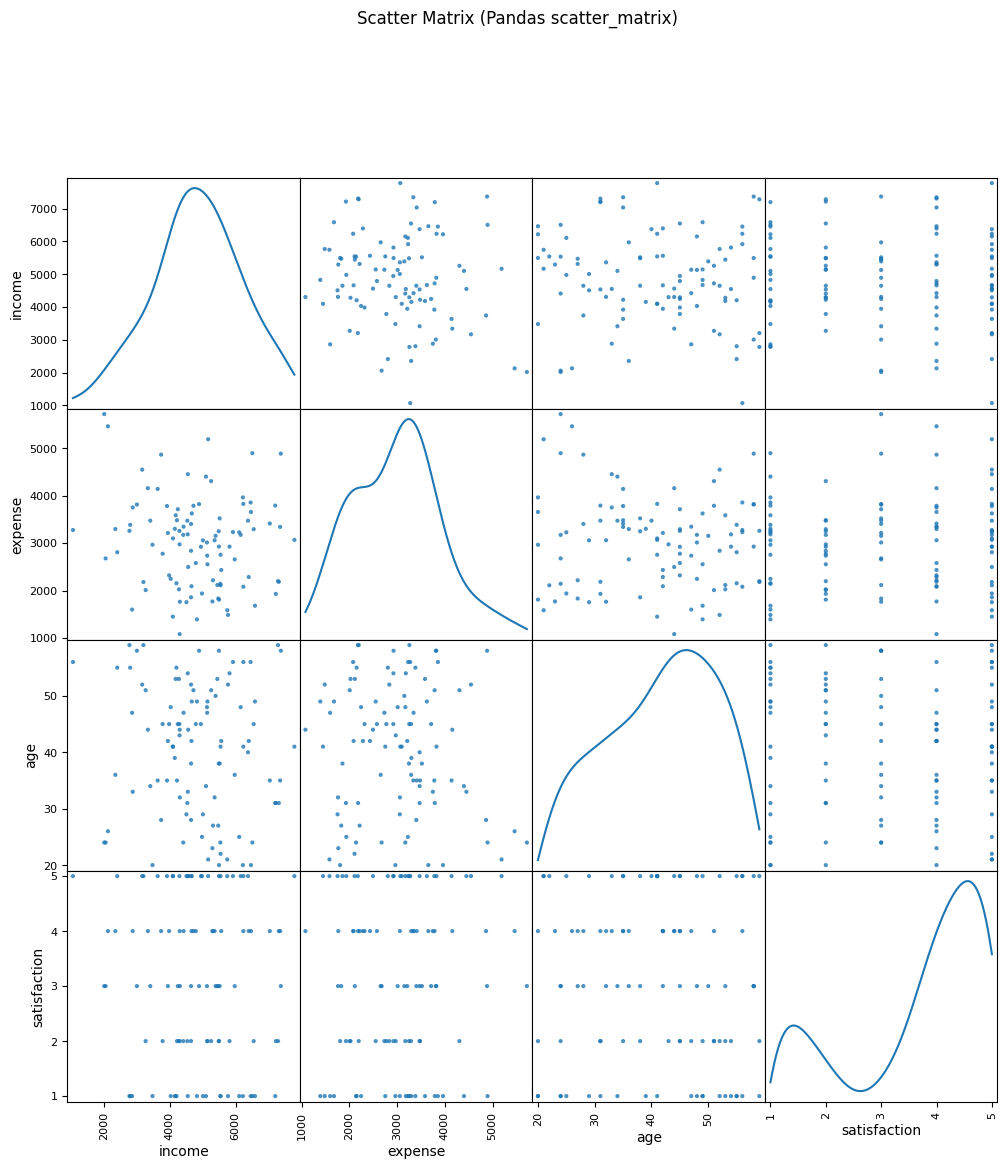

<Figure size 1200x1200 with 0 Axes>

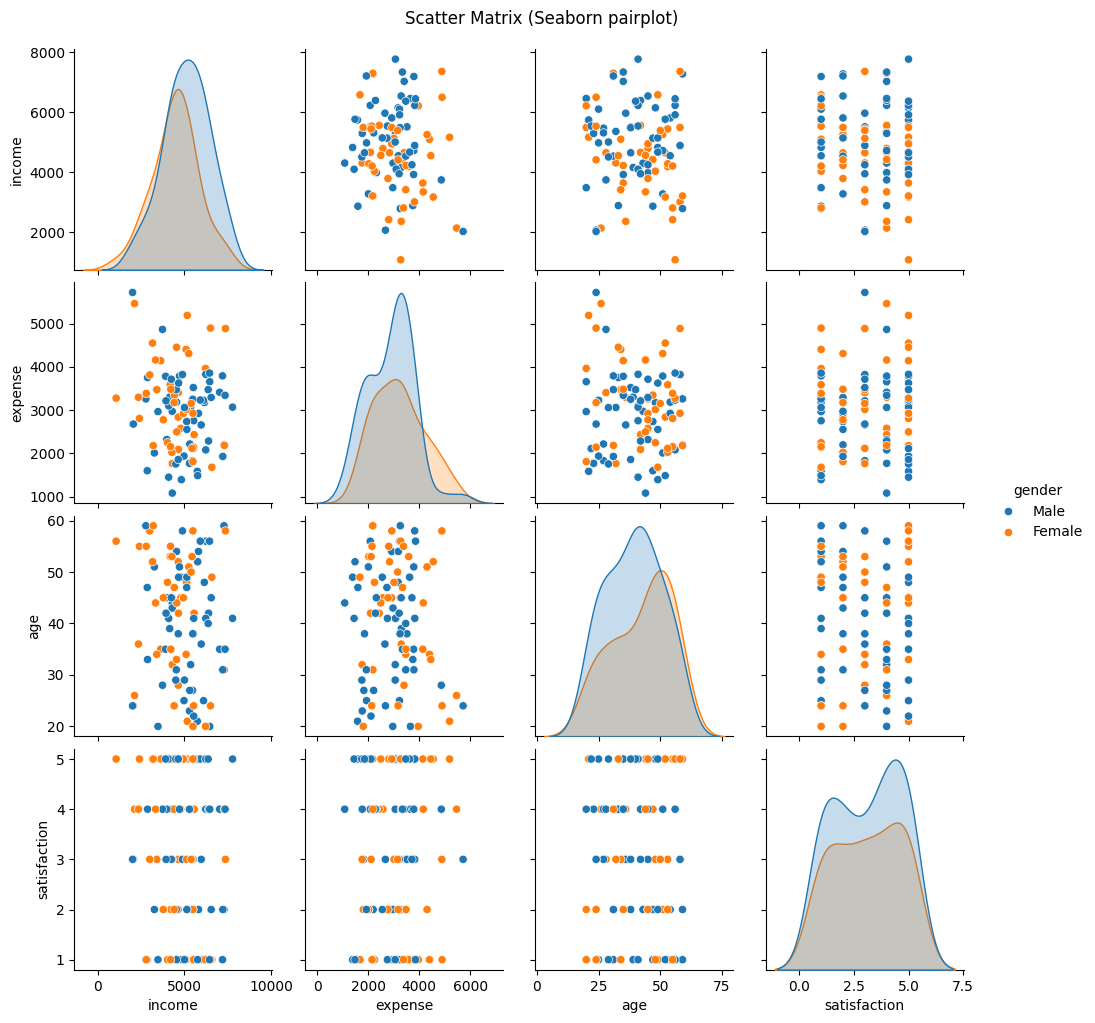

In [ ]:
# pandas 산점도 행렬
# 숫자형 컬럼만 선택
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 12))
scatter_matrix(numeric_df, alpha=0.8, figsize=(12, 12), diagonal='kde')
plt.suptitle('Scatter Matrix (Pandas scatter_matrix)', y=1.02) # 제목 위치 조정을 위해 y 조정
plt.show()

# seaborn pairplot
# hue를 추가하여 성별에 따른 관계를 볼 수 있음
plt.figure(figsize=(12, 12))
sns.pairplot(df, vars=['income', 'expense', 'age', 'satisfaction'], hue='gender', diag_kind='kde')
plt.suptitle('Scatter Matrix (Seaborn pairplot)', y=1.02)
plt.show()

#### 10.2 상관 계수

In [ ]:
# 수입과 지출 간의 상관 계수
correlation_income_expense = df['income'].corr(df['expense'])
print(f"Correlation between income and expense: {correlation_income_expense:.2f}")

# 연령과 수입 간의 상관 계수
correlation_age_income = df['age'].corr(df['income'])
print(f"Correlation between age and income: {correlation_age_income:.2f}")

Correlation between income and expense: -0.14
Correlation between age and income: -0.09


#### 10.3 상관 계수 행렬 시각화 (Heatmap)

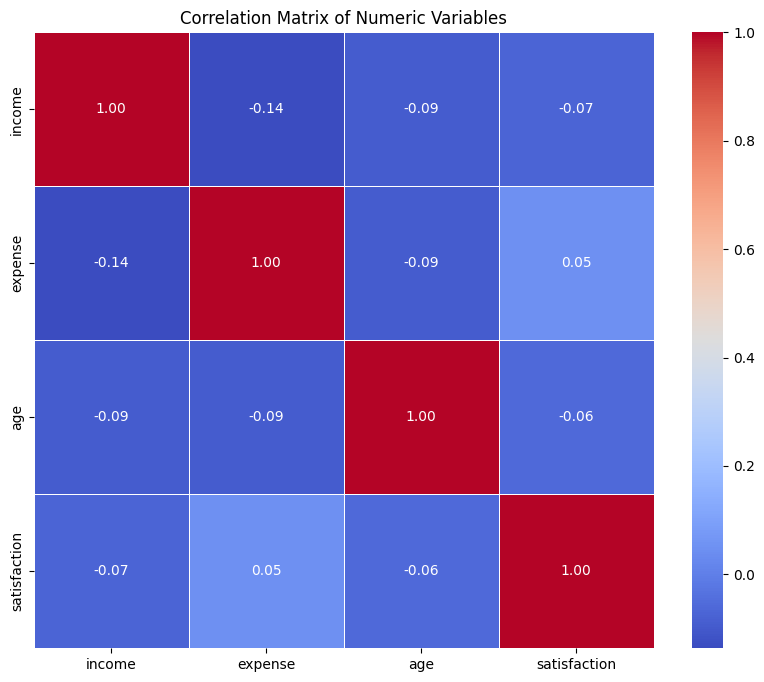

In [ ]:
# 숫자형 변수들의 상관 계수 행렬 계산
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()